# D-RISE analysis (RF-DETR)

Black-box saliency via random masking; implementation lives in `dermato_ai/rfdetr-xai/src/rfdetr_drise_run.py`.

**Phase 2** implements per-detection D-RISE. For each RF-DETR detection on the original image, we draw random masks, run the detector on masked images, and score each masked prediction with a **continuous** target similarity: class confidence multiplied by IoU with the original target box (optional \( \mathrm{IoU}^\gamma \)). IoU-weighted matching **reduces target switching** by assigning lower scores to predictions that do not spatially match the original target box. We save **raw** saliency for metrics and **display-normalized** maps for figures, log target-matching statistics, run mask-count convergence and deletion/insertion curves, and optionally compare to expert masks.

We verify per-detection behaviour by comparing **spatial peaks**, **target-box overlap**, and **deletion/insertion** response—not by mean saliency (which mostly reflects masking and smoothing). An explanation is more meaningful if high-saliency regions overlap the target or expert annotation and **removing** those regions **drops** the target score.


In [1]:
from pathlib import Path
import os
import sys
import site

def find_repo_root(marker="pyproject.toml", max_depth=10):
    current = Path.cwd().resolve()
    for _ in range(max_depth):
        if (current / marker).exists():
            return current
        current = current.parent
    return None

def prefer_venv_site_packages():
    venv_prefix = str(Path(sys.prefix).resolve())
    venv_sites = [p for p in site.getsitepackages() if p.startswith(venv_prefix)]
    cleaned = [p for p in sys.path if not (p.startswith("/net/software/") and "site-packages" in p)]
    for p in reversed(venv_sites):
        if p in cleaned:
            cleaned.remove(p)
        cleaned.insert(0, p)
    sys.path[:] = cleaned
    cached = sys.modules.get("regex")
    cached_path = getattr(cached, "__file__", "") if cached is not None else ""
    if cached_path.startswith("/net/software/"):
        for name in list(sys.modules.keys()):
            if name == "regex" or name.startswith("regex."):
                del sys.modules[name]

REPO_ROOT = find_repo_root()
if REPO_ROOT is None:
    REPO_ROOT = Path("/net/tscratch/people/plgbmruszaj/dermatoscopy_ai")

RFD_XAI_ROOT = REPO_ROOT / "dermato_ai" / "rfdetr-xai"
os.chdir(RFD_XAI_ROOT)
sys.path.insert(0, str(RFD_XAI_ROOT / "src"))
sys.path.insert(0, str(REPO_ROOT))
prefer_venv_site_packages()

from dermato_ai.coco.dataset_manager import COCODatasetManager

DATA_ZIP_DIR = REPO_ROOT / "data" / "coco_images_zip"
manager = COCODatasetManager.from_archive(directory=DATA_ZIP_DIR, archive_pattern="*.zip")
dataset_dir = Path(manager.json_path).parent
dedup_coco_json = dataset_dir / "result_dedup_for_drise.json"
manager.save(str(dedup_coco_json))
COCO_JSON = str(dedup_coco_json)
IMAGES_DIR = str(dataset_dir / "images")
OUTPUT_DIR = str(dataset_dir / "drise_outputs")

CHECKPOINT = "/net/tscratch/people/plgbmruszaj/rfdetr_all_data_results_yellow_large_20260507_150528/rfdetr_large_best_2573873/checkpoints/checkpoint_best_ema.pth"

print("COCO JSON:", COCO_JSON)
print("Images:", IMAGES_DIR)
print("Output:", OUTPUT_DIR)


INFO: Found newest archive: project-5-at-2026-05-07-11-56-9b7fa76c.zip
INFO: Unpacking project-5-at-2026-05-07-11-56-9b7fa76c.zip to /net/tscratch/people/plgbmruszaj/dermatoscopy_ai/data/coco_images_zip/extracted
INFO: Extraction complete
INFO: Found result.json at: /net/tscratch/people/plgbmruszaj/dermatoscopy_ai/data/coco_images_zip/extracted/result.json
INFO: Loading COCO dataset from /net/tscratch/people/plgbmruszaj/dermatoscopy_ai/data/coco_images_zip/extracted/result.json
INFO: Loaded 314 images, 1299 annotations
INFO: Collapsed duplicate image passes: removed 97 image entries and 0 annotations
INFO: Valid COCO structure: 217 images, 1299 annotations, 10 categories
INFO: Fixed 217 image paths
INFO: Saved dataset to /net/tscratch/people/plgbmruszaj/dermatoscopy_ai/data/coco_images_zip/extracted/result_dedup_for_drise.json


COCO JSON: /net/tscratch/people/plgbmruszaj/dermatoscopy_ai/data/coco_images_zip/extracted/result_dedup_for_drise.json
Images: /net/tscratch/people/plgbmruszaj/dermatoscopy_ai/data/coco_images_zip/extracted/images
Output: /net/tscratch/people/plgbmruszaj/dermatoscopy_ai/data/coco_images_zip/extracted/drise_outputs


In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.patches as patches
from pathlib import Path
from PIL import Image

try:
    from IPython.display import display
except ImportError:
    display = print

from rfdetr_load import load_rfdetr
from rfdetr_drise_run import (
    run_drise_per_target,
    resize_hw_map,
    normalize_saliency_for_display,
    box_energy_fraction,
    saliency_map_correlation,
    deletion_insertion_curves,
    expert_energy_fraction,
    pointing_game_hit,
    iou_dice_vs_expert,
)

# Interactive/debug: small mask counts. Set DEMO_FAST = False for thesis runs (slow).
DEMO_FAST = True
MASK_SCHEDULE = [64, 128, 256] if DEMO_FAST else [500, 1000, 2000, 5000]
PER_DET_MASKS = 128 if DEMO_FAST else 1000
DR_GAMMA = 1.0

# Optional expert annotation [H,W] aligned with image (0/1). Loaded if file exists.
EXPERT_MASK_PATH = None

OUTPUT_SUB = Path(OUTPUT_DIR) / "drise_phase2"
OUTPUT_SUB.mkdir(parents=True, exist_ok=True)

# Multi-image panel: 1 = only first image (`per_det_results`); N = up to N sample images with detections.
PANEL_NUM_IMAGES = 5
PANEL_IMAGES_SEED = 0


In [3]:
model = load_rfdetr("large", CHECKPOINT)
first_image_path = Path(IMAGES_DIR) / sorted(Path(IMAGES_DIR).glob("*"))[0].name
pil_img = Image.open(first_image_path).convert("RGB")
det = model.predict(pil_img, threshold=0.25)
print(first_image_path.name, "— detections:", 0 if det is None else len(det))


[2026-05-07 21:36:07] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-05-07 21:36:07] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-05-07 21:36:07] [WARNING] rf-detr - Checkpoint has 1 classes but model is configured for 90. Using checkpoint class count (1). Pass num_classes=1 to suppress this warning.
[2026-05-07 21:36:08] [WARNING] rf-detr - Model is not optimized for inference. Latency may be higher than expected. You can optimize the model for inference by calling model.optimize_for_inference().
[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


0585fe06-0fb0-4e30-8d1e-ebf137dee250.jpg — detections: 4


## Mask-count convergence

We increase the number of masks until the saliency map **correlation** between successive budgets on this schedule stabilizes (Pearson \(r\) on flattened raw maps, same spatial size). Use `DEMO_FAST = False` and the full `[500, 1000, 2000, 5000]` schedule for reporting.


In [4]:
convergence_rows = []
prev_raw = None
if det is not None and len(det) > 0:
    tb0 = det.xyxy[0]
    tc0 = int(det.class_id[0])
    for nmasks in MASK_SCHEDULE:
        out = run_drise_per_target(
            model,
            first_image_path,
            target_box_xyxy=tb0,
            target_class_id=tc0,
            target_confidence=float(det.confidence[0]),
            num_masks=nmasks,
            mask_res=(8, 8),
            gamma=DR_GAMMA,
            seed=42,
        )
        raw = out["raw_saliency"]
        raw_r = resize_hw_map(raw, (pil_img.size[1], pil_img.size[0]))
        corr = np.nan if prev_raw is None else saliency_map_correlation(
            resize_hw_map(prev_raw, (pil_img.size[1], pil_img.size[0])), raw_r
        )
        convergence_rows.append({"N_masks": nmasks, "corr_vs_previous_budget": corr})
        prev_raw = raw
    display(pd.DataFrame(convergence_rows))
else:
    print("No detections — skip convergence.")


[2026-05-07 21:36:10] [WARNING] rf-detr - predict() encountered class_id values out of range [0, 1): [np.int64(1)] — mapping to empty string


,N_masks,corr_vs_previous_budget
0,64,NaN
1,128,0.787361
2,256,0.888099


## Per-detection D-RISE (continuous target score)

For each detection: **target score** = \(\max\) over same-class predictions of \(\mathrm{conf} \cdot \mathrm{IoU}(\mathrm{pred\_box}, \mathrm{target\_box})^{\gamma}\). Raw maps are saved as `*_raw_saliency.npy`; PNGs use display normalization only.

Log columns include **matched_detection_rate** = fraction of masks with score \> 0 (low values ⇒ noisy explanation because masking destroys the detection often).


In [5]:
per_det_results = []

def maybe_load_expert(hw):
    if EXPERT_MASK_PATH is None:
        return None
    p = Path(EXPERT_MASK_PATH)
    if not p.is_file():
        return None
    em = np.array(Image.open(p).convert("L"))
    em = (em > 0).astype(np.uint8)
    if em.shape != hw:
        raise ValueError(f"Expert mask {em.shape} != saliency {hw}")
    return em

if det is not None and len(det) > 0:
    metrics_rows = []
    for det_idx in range(len(det)):
        tb = det.xyxy[det_idx]
        tc = int(det.class_id[det_idx])
        cf = float(det.confidence[det_idx])
        out = run_drise_per_target(
            model,
            first_image_path,
            target_box_xyxy=tb,
            target_class_id=tc,
            target_confidence=cf,
            num_masks=PER_DET_MASKS,
            mask_res=(8, 8),
            gamma=DR_GAMMA,
            seed=100 + det_idx,
        )
        raw = resize_hw_map(out["raw_saliency"], (pil_img.size[1], pil_img.size[0]))
        vis = normalize_saliency_for_display(raw)
        stem = f"{first_image_path.stem}_det{det_idx}"
        np.save(OUTPUT_SUB / f"{stem}_raw_saliency.npy", raw)
        rgb_vis = (cm.magma(vis)[:, :, :3] * 255).astype(np.uint8)
        Image.fromarray(rgb_vis).save(OUTPUT_SUB / f"{stem}_normalized_saliency.png")

        be = box_energy_fraction(raw, tb)
        row = dict(out["meta"])
        row.update({"det_idx": det_idx, "box_energy_in_target_box": be})
        em = maybe_load_expert(raw.shape)
        if em is not None:
            row["expert_energy_fraction"] = expert_energy_fraction(raw, em)
            pg, pg_xy = pointing_game_hit(raw, em)
            row["pointing_game_hit"] = pg
            iou_e, dice_e = iou_dice_vs_expert(raw, em)
            row["iou_saliency_vs_expert"] = iou_e
            row["dice_saliency_vs_expert"] = dice_e
        metrics_rows.append(row)
        per_det_results.append(
            {"det_idx": det_idx, "box": tb, "confidence": cf, "raw": raw, "vis": vis, "meta": out["meta"], "row": row}
        )

    summary_df = pd.DataFrame(metrics_rows)
    display(summary_df)
    summary_df.to_csv(OUTPUT_SUB / "per_detection_metrics.csv", index=False)
    with open(OUTPUT_SUB / "per_detection_metrics.json", "w", encoding="utf-8") as f:
        json.dump(metrics_rows, f, indent=2)
else:
    print("No detections — skip per-detection run.")


,target_class,target_confidence,target_box,number_of_masks,mask_resolution,mask_mean_visible_fraction,mean_target_score,max_target_score,matched_detection_rate,gamma,center_affinities,det_idx,box_energy_in_target_box
0,0,0.851296,"[861.7444458007812, 713.0776977539062, 922.780...",128,"[8, 8]",0.499168,0.348771,0.836749,0.828125,1.0,True,0,0.085600
1,0,0.815465,"[553.953125, 488.86181640625, 625.123474121093...",128,"[8, 8]",0.493725,0.328991,0.783189,0.875000,1.0,True,1,0.324052
2,0,0.766875,"[679.9337768554688, 821.2462158203125, 793.476...",128,"[8, 8]",0.497187,0.258441,0.816245,0.804688,1.0,True,2,0.112030
3,0,0.717560,"[496.7676086425781, 800.6829223632812, 539.074...",128,"[8, 8]",0.502522,0.215735,0.693231,0.718750,1.0,True,3,0.489649


### Figure: original with target vs other boxes

The **target** detection is highlighted separately from non-target detections for visual inspection (figure styling only, not part of the scoring formula).

Set **`PANEL_NUM_IMAGES`** (imports cell): `1` = only the first dataset image using `per_det_results`; **`N > 1`** = up to **N** images with detections — the first image reuses cached results from the metrics cell; additional images are sampled randomly (`PANEL_IMAGES_SEED`). Each row is one **detection** (so multiple rows per image if there are multiple boxes).


In [ ]:
import random


def _per_det_for_image(img_path, pil_i, det_i, seed_base: int):
    """D-RISE per detection (same outputs as the metrics cell)."""
    rows = []
    if det_i is None or len(det_i) == 0:
        return rows
    for det_idx in range(len(det_i)):
        tb = det_i.xyxy[det_idx]
        tc = int(det_i.class_id[det_idx])
        cf = float(det_i.confidence[det_idx])
        out = run_drise_per_target(
            model,
            img_path,
            target_box_xyxy=tb,
            target_class_id=tc,
            target_confidence=cf,
            num_masks=PER_DET_MASKS,
            mask_res=(8, 8),
            gamma=DR_GAMMA,
            seed=seed_base + det_idx,
        )
        raw = resize_hw_map(out["raw_saliency"], (pil_i.size[1], pil_i.size[0]))
        vis = normalize_saliency_for_display(raw)
        stem = f"{Path(img_path).stem}_det{det_idx}"
        np.save(OUTPUT_SUB / f"{stem}_raw_saliency.npy", raw)
        rgb_vis = (cm.magma(vis)[:, :, :3] * 255).astype(np.uint8)
        Image.fromarray(rgb_vis).save(OUTPUT_SUB / f"{stem}_normalized_saliency.png")
        row = dict(out["meta"])
        row.update({"det_idx": det_idx, "box_energy_in_target_box": box_energy_fraction(raw, tb)})
        em = maybe_load_expert(raw.shape)
        if em is not None:
            row["expert_energy_fraction"] = expert_energy_fraction(raw, em)
            pg, pg_xy = pointing_game_hit(raw, em)
            row["pointing_game_hit"] = pg
            iou_e, dice_e = iou_dice_vs_expert(raw, em)
            row["iou_saliency_vs_expert"] = iou_e
            row["dice_saliency_vs_expert"] = dice_e
        rows.append(
            {"det_idx": det_idx, "box": tb, "confidence": cf, "raw": raw, "vis": vis, "meta": out["meta"], "row": row}
        )
    return rows


def build_panel_runs():
    """Build [{path, pil, det, rows}, ...] for the figure."""
    runs = []
    if PANEL_NUM_IMAGES <= 1:
        if per_det_results:
            runs.append({"path": first_image_path, "pil": pil_img, "det": det, "rows": per_det_results})
        return runs

    used = set()
    if per_det_results and det is not None and len(det):
        runs.append({"path": first_image_path, "pil": pil_img, "det": det, "rows": per_det_results})
        used.add(Path(first_image_path).resolve())

    rng = random.Random(PANEL_IMAGES_SEED)
    pool = [p for p in Path(IMAGES_DIR).glob("*") if p.is_file()]
    rng.shuffle(pool)

    seed_img = 1000
    for p in pool:
        if len(runs) >= PANEL_NUM_IMAGES:
            break
        pr = Path(p).resolve()
        if pr in used:
            continue
        pil_i = Image.open(p).convert("RGB")
        d_i = model.predict(pil_i, threshold=0.25)
        if d_i is None or len(d_i) == 0:
            continue
        rows = _per_det_for_image(p, pil_i, d_i, seed_base=seed_img)
        seed_img += 100
        runs.append({"path": p, "pil": pil_i, "det": d_i, "rows": rows})
        used.add(pr)

    return runs


panel_runs = build_panel_runs()
flat = [(run, r) for run in panel_runs for r in run["rows"]]

if flat:
    n = len(flat)
    fig, axes = plt.subplots(n, 3, figsize=(14, min(4 * n, 26)))
    if n == 1:
        axes = np.asarray(axes).reshape(1, -1)
    for i, (run, r) in enumerate(flat):
        arr = np.asarray(run["pil"])
        d_obj = run["det"]
        di = r["det_idx"]
        axes[i, 0].imshow(arr)
        for j, box in enumerate(d_obj.xyxy):
            x1, y1, x2, y2 = box
            if j == di:
                axes[i, 0].add_patch(
                    patches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=2.5, edgecolor="white", facecolor="none")
                )
            else:
                axes[i, 0].add_patch(
                    patches.Rectangle(
                        (x1, y1), x2 - x1, y2 - y1, linewidth=1.5, edgecolor="orange", facecolor="none", alpha=0.55
                    )
                )
        lbl = Path(run["path"]).name
        axes[i, 0].set_title(f"{lbl}\ndet {di}: target vs others")
        axes[i, 0].axis("off")
        im1 = axes[i, 1].imshow(r["vis"], cmap="magma")
        axes[i, 1].set_title("D-RISE (display norm.)")
        axes[i, 1].axis("off")
        plt.colorbar(im1, ax=axes[i, 1], fraction=0.046)
        axes[i, 2].imshow(arr, alpha=0.65)
        axes[i, 2].imshow(r["vis"], cmap="magma", alpha=0.45)
        axes[i, 2].set_title("Overlay")
        axes[i, 2].axis("off")

    names = ", ".join(Path(r["path"]).name for r in panel_runs)
    plt.suptitle(f"Per-detection D-RISE ({len(panel_runs)} image(s)): {names}", fontsize=11)
    plt.tight_layout()
    out_png = OUTPUT_SUB / ("per_detection_panel.png" if PANEL_NUM_IMAGES <= 1 else "per_detection_panel_multi.png")
    plt.savefig(out_png, dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved:", out_png)
else:
    print("No figures — no panel rows (run per-detection cell and/or set PANEL_NUM_IMAGES / detection threshold).")



## Deletion / insertion (target score)

**Deletion:** blur the most salient pixels first; **insertion:** start from a blurred image and reveal most salient pixels first. Both curves track the same **D-RISE target score** as the explanation loop (class × IoU).


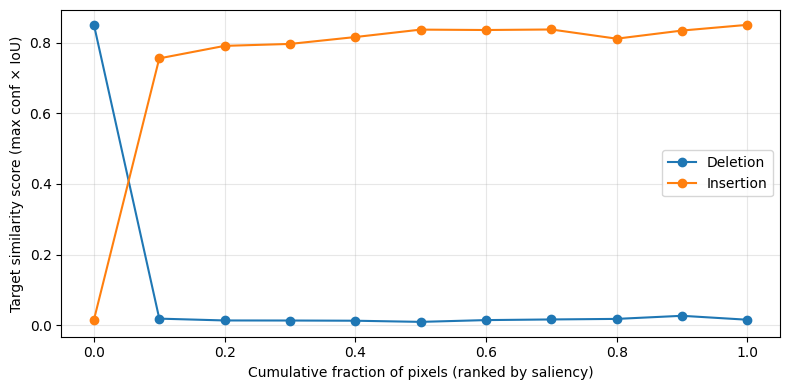

In [7]:
if per_det_results:
    r0 = per_det_results[0]
    tb = det.xyxy[r0["det_idx"]]
    tc = int(det.class_id[r0["det_idx"]])
    curves = deletion_insertion_curves(
        model,
        pil_img,
        target_box_xyxy=tb,
        target_class_id=tc,
        saliency_hw=r0["raw"],
        gamma=DR_GAMMA,
        steps=10 if DEMO_FAST else 20,
    )
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(curves["fractions"], curves["deletion_target_scores"], marker="o", label="Deletion")
    ax.plot(curves["fractions"], curves["insertion_target_scores"], marker="o", label="Insertion")
    ax.set_xlabel("Cumulative fraction of pixels (ranked by saliency)")
    ax.set_ylabel("Target similarity score (max conf × IoU)")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUTPUT_SUB / "deletion_insertion.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("Skip deletion/insertion.")


## Optional: quick multi-image batch

Small batch to sanity-check multiple images without duplicating the whole pipeline above.


In [10]:
import random

rng = random.Random(0)
paths = [p for p in Path(IMAGES_DIR).glob("*") if p.is_file()]
sample = rng.sample(paths, min(30, len(paths))) if paths else []
batch_meta = []
for p in sample:
    pil_b = Image.open(p).convert("RGB")
    d_b = model.predict(pil_b, threshold=0.25)
    if d_b is None or len(d_b) == 0:
        continue
    out_b = run_drise_per_target(
        model,
        p,
        target_box_xyxy=d_b.xyxy[0],
        target_class_id=int(d_b.class_id[0]),
        target_confidence=float(d_b.confidence[0]),
        num_masks=min(PER_DET_MASKS, 64),
        mask_res=(8, 8),
        gamma=DR_GAMMA,
        seed=7,
    )
    raw_b = resize_hw_map(out_b["raw_saliency"], (pil_b.size[1], pil_b.size[0]))
    batch_meta.append({"image": p.name, **out_b["meta"], "box_energy": box_energy_fraction(raw_b, d_b.xyxy[0])})

if batch_meta:
    display(pd.DataFrame(batch_meta))
else:
    print("No batch results.")


,image,target_class,target_confidence,target_box,number_of_masks,mask_resolution,mask_mean_visible_fraction,mean_target_score,max_target_score,matched_detection_rate,gamma,center_affinities,box_energy
0,11e123d1-b9bf-4788-a9f9-246b0a003bf5.jpg,0,0.875633,"[861.7852172851562, 637.1160888671875, 938.042...",64,"[8, 8]",0.505161,0.252055,0.863686,0.875000,1.0,True,0.084120
1,38ad26d5-5d32-4e0e-9bcd-cb8f97c9673f.jpg,0,0.852113,"[1421.07177734375, 266.0257873535156, 1715.451...",64,"[8, 8]",0.505161,0.187061,0.795658,0.937500,1.0,True,0.661849
2,0c0a8d26-29d7-4a83-9f1c-bd7d4eff83df.jpg,0,0.907374,"[1130.062744140625, 10.344228744506836, 1654.0...",64,"[8, 8]",0.505161,0.288700,0.793959,1.000000,1.0,True,0.702188
3,cf7f06c0-b7f4-43a4-99ef-829a3bc10858.jpg,0,0.872052,"[670.2178344726562, 296.46392822265625, 787.15...",64,"[8, 8]",0.505161,0.279668,0.802654,0.750000,1.0,True,0.127095
4,9427202e-B6B594FD-3E73-4B65-B5A9-FEB91A19E687.jpg,0,0.829013,"[674.7181396484375, 243.08285522460938, 762.95...",64,"[8, 8]",0.505161,0.317819,0.835641,0.890625,1.0,True,0.086080
5,cf89026a-b55b-4f26-be92-2a59929481d1.jpg,0,0.899850,"[701.6148681640625, 669.7390747070312, 872.967...",64,"[8, 8]",0.505161,0.431890,0.875441,0.796875,1.0,True,0.187328
6,e268c35f-62c8-4c80-bf2a-b701a5c7ccb9.jpg,0,0.870850,"[752.2989501953125, 791.1616821289062, 893.480...",64,"[8, 8]",0.505161,0.385199,0.839282,0.906250,1.0,True,0.049517
7,b3cc03dc-08A6E4AA-E78F-40FD-B54C-BA5A011B0E02.jpg,0,0.833989,"[805.8995361328125, 552.31884765625, 879.32836...",64,"[8, 8]",0.505161,0.310556,0.807303,0.703125,1.0,True,0.065530
8,ee1da242-27bf-4452-ad53-50bbc4b19f83.jpg,0,0.879411,"[857.1847534179688, 335.79217529296875, 924.83...",64,"[8, 8]",0.505161,0.442555,0.858363,0.671875,1.0,True,0.103954
9,58d70618-4b6c-4893-907f-33623a56915b.jpg,0,0.916129,"[693.5059204101562, 404.8877258300781, 930.902...",64,"[8, 8]",0.505161,0.415812,0.913662,0.968750,1.0,True,0.461692


### Thesis wording

- **IoU weighting:** IoU-weighted matching reduces target switching by assigning lower scores to detections that do not spatially match the original target box. D-RISE is black-box: masked predictions are scored by similarity to the target detection (here: same class, continuous conf × IoU).
- **Validation:** Judge explanations by spatial overlap with the target (and expert) region and by deletion/insertion behaviour—not by mean saliency magnitude.
- **Convergence:** Report that mask budgets were increased until correlation between successive saliency maps on the schedule stabilized (see table above).
